# Imports and Environment Setup


In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Ignore the known KMeans warning on Windows with MKL
warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL",
    category=UserWarning,
    module="sklearn.cluster._kmeans",
)


# Load and Inspect the Dataset
This section loads the red wine quality dataset into a pandas DataFrame, shows the first few rows, checks for missing values, and prints the dataset structure including column names, non-null counts, and data types.

In [3]:
# Load the dataset using semicolon as the separator
df = pd.read_csv("winequality-red.csv", sep=";")

# Display the first five rows of the dataset
df.head()

# Check for missing values in each column
df.isnull().sum()

# Display dataset structure and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


# Feature Scaling and Normalization

This section separates the input features from the target variable by removing the quality column. Then, it standardizes the features using StandardScaler and normalizes the transformed values to the range [0, 1] using MinMaxScaler.

In [4]:
# Remove the target column to create the feature set
X = df.drop("quality", axis=1)

# Standardize the features to have zero mean and unit variance
scaler_std = StandardScaler()
X_whitened = scaler_std.fit_transform(X)

# Normalize the standardized features to the range [0, 1]
scaler_mm = MinMaxScaler()
X_normalized = scaler_mm.fit_transform(X_whitened)


# Correlation Heatmap
This section visualizes the correlation matrix of the dataset using a heatmap. It helps identify the strength and direction of relationships between numerical variables.

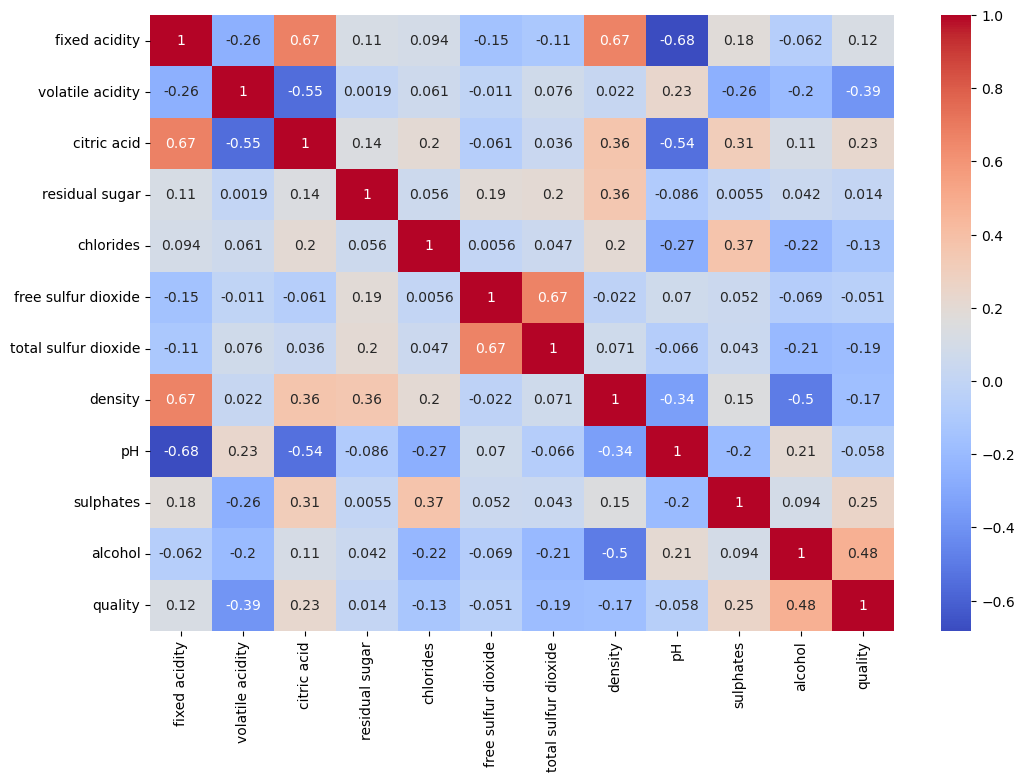

In [5]:
# Create a figure for the correlation heatmap
plt.figure(figsize=(12, 8))

# Plot the correlation matrix with annotations
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

# Display the plot
plt.show()


# Feature Selection
This section keeps only the selected features that will be used for the next step of the analysis or modeling.

In [6]:
selected_features = ["alcohol", "sulphates", "citric acid"]
X_selected = df[selected_features]


# Elbow Method for K-Means
This section applies the elbow method to help choose the best number of clusters for K-Means. It fits models with different values of k, stores the inertia for each one, and plots the results.

C:\ProgramData\anaconda3\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~

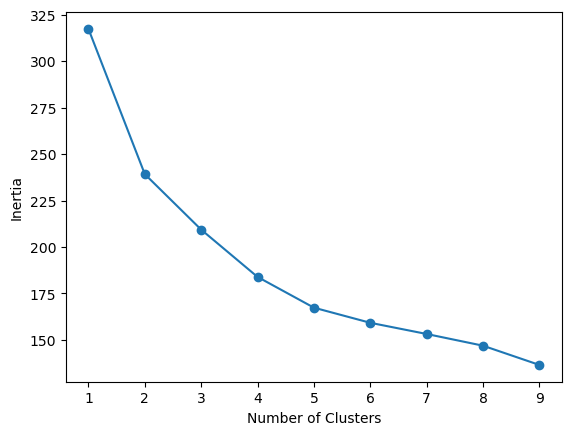

In [7]:
# Store inertia values for different cluster counts
inertia = []

# Try K values from 1 to 9 and record the model inertia
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_normalized)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


# K-Means Clustering
This section applies K-Means clustering with 3 clusters and stores the cluster labels in the dataset. It then visualizes the clustering result using alcohol and sulphates as the plotted features.

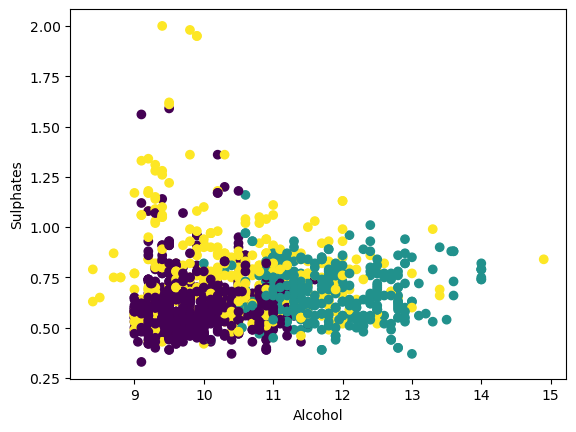

In [8]:
# Fit K-Means with the chosen number of clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_normalized)

# Add cluster labels to the dataset
df["cluster"] = clusters

# Visualize the clusters using two important features
plt.scatter(df["alcohol"], df["sulphates"], c=clusters)
plt.xlabel("Alcohol")
plt.ylabel("Sulphates")
plt.show()


# KNN Classification Based on Clusters
In this section, the cluster labels are used as target classes for classification. The data is split into training and testing subsets, and a KNN model is trained on the normalized features. Finally, the accuracy of the model is evaluated and displayed.

In [9]:
# Set the target variable to the newly created cluster labels
y = df["cluster"]

# Split the normalized data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

# Initialize and train the K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict labels on the test set
pred_knn = knn.predict(X_test)

# Calculate and print the classification accuracy
knn_acc = accuracy_score(y_test, pred_knn)
print(f"KNN Accuracy: {knn_acc:.4f}")


KNN Accuracy: 0.9344


# Decision Tree Classification
This section trains a Decision Tree classifier using the training data and evaluates its performance on the test set. The model accuracy is then calculated and printed.

In [10]:
# Initialize and train the Decision Tree classifier
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Predict labels on the test set
pred_dt = dt.predict(X_test)

# Calculate and print the classification accuracy
dt_acc = accuracy_score(y_test, pred_dt)
print(f"Decision Tree Accuracy: {dt_acc:.4f}")


Decision Tree Accuracy: 0.9125


# Decision Tree Visualization
This section visualizes the trained Decision Tree model. The colored nodes help show how the model splits the data to make classification decisions.

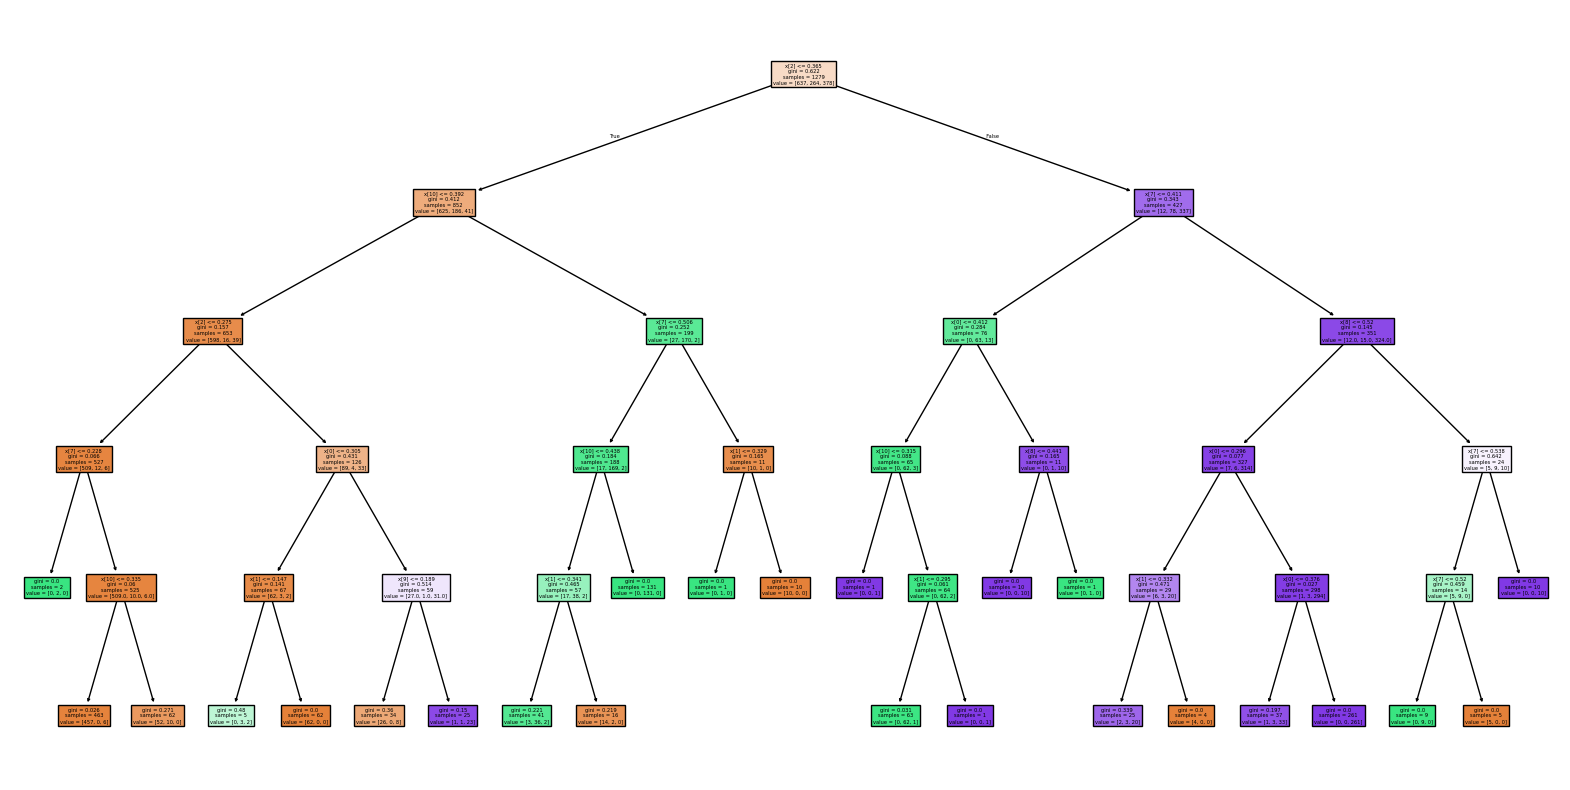

In [11]:
# Create a figure for the decision tree plot
plt.figure(figsize=(20, 10))

# Visualize the trained decision tree
plot_tree(dt, filled=True)

# Display the plot
plt.show()


# Model Accuracy Comparison
This section prints a comparison of the accuracy scores achieved by the K-Nearest Neighbors (KNN) and Decision Tree classifiers.

In [12]:
# Print the accuracy scores for both KNN and Decision Tree models
print(f"KNN Accuracy: {knn_acc:.4f}")
print(f"Decision Tree Accuracy: {dt_acc:.4f}")


KNN Accuracy: 0.9344
Decision Tree Accuracy: 0.9125


# Feature Selection using Genetic Algorithm for Regression
This section implements a Genetic Algorithm to find the optimal subset of features for a Linear Regression model predicting wine quality.

Data Preparation: It separates the features (X) by dropping quality and cluster, and sets quality as the regression target (y_reg).
Fitness Function: The fitness function evaluates a given set of features (represented by a binary chromosome). It uses 5-fold cross-validation with LinearRegression and returns the mean R-squared score as the fitness. If no features are selected, fitness is 0.
Genetic Algorithm:
Initializes a random population of chromosomes.
Iterates for a set number of generations:
Calculates the fitness of each individual.
Selects the top 10 individuals as parents.
Creates children through crossover (combining parts of two parents) and mutation (randomly flipping bits in a chromosome).
Replaces the old population with the new generation.
Result: After the evolution, it identifies the best chromosome and prints the names of the features selected by the algorithm.
The goal here is to automatically discover which features are most predictive of wine quality using a regression approach.

In [13]:
# Prepare features and classification target
X = df.drop(["quality", "cluster"], axis=1)
y = df["cluster"]

def fitness(chromosome):
    # Select features where chromosome value is 1
    features = X.columns[np.array(chromosome) == 1]
    
    # Return 0 if no feature is selected
    if len(features) == 0:
        return 0

    # Use a simple classifier to evaluate selected features
    model = DecisionTreeClassifier(random_state=42)
    
    # Compute mean cross-validation accuracy
    score = cross_val_score(
        model,
        X[features],
        y,
        cv=5,
        scoring="accuracy"
    ).mean()
    
    return score

# Genetic Algorithm parameters
population_size = 20
num_features = X.shape[1]
num_generations = 20

# Initialize population with random binary chromosomes
population = np.random.randint(0, 2, (population_size, num_features))

for generation in range(num_generations):
    # Evaluate fitness for each chromosome
    scores = [fitness(ch) for ch in population]
    
    # Select the top 10 chromosomes as parents
    sorted_idx = np.argsort(scores)[-10:]
    parents = population[sorted_idx]
    
    children = []
    
    while len(children) < population_size:
        # Randomly choose two parents
        p1, p2 = parents[np.random.randint(0, 10, 2)]
        
        # Perform one-point crossover
        crossover_point = np.random.randint(1, num_features - 1)
        child = np.concatenate([p1[:crossover_point], p2[crossover_point:]])
        
        # Apply random mutation
        if np.random.rand() < 0.1:
            idx = np.random.randint(0, num_features)
            child[idx] = 1 - child[idx]
        
        children.append(child)
    
    # Update population
    population = np.array(children)

# Select the best chromosome from the final population
best = population[np.argmax([fitness(ch) for ch in population])]
ga_features = X.columns[best == 1]

print("Selected Features:", ga_features)


Selected Features: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides',
       'free sulfur dioxide', 'total sulfur dioxide', 'alcohol'],
      dtype='object')


# Model Performance with Genetically Selected Features
This section evaluates the performance of the KNN and Decision Tree models using only the features selected by the Genetic Algorithm. It then compares these new accuracies with the original accuracies (before GA feature selection) and prints the results in a table for easy comparison. This helps to understand if the GA-selected features improve or degrade model performance.

In [14]:
# Use GA-selected features for classification
X_ga = df[ga_features]
y = df["cluster"]

# Split data using GA-selected features
X_train_ga, X_test_ga, y_train_ga, y_test_ga = train_test_split(
    X_ga, y, test_size=0.2, random_state=42
)

# Re-train and evaluate KNN
knn.fit(X_train_ga, y_train_ga)
ga_knn_acc = accuracy_score(y_test_ga, knn.predict(X_test_ga))

# Re-train and evaluate Decision Tree
dt.fit(X_train_ga, y_train_ga)
ga_dt_acc = accuracy_score(y_test_ga, dt.predict(X_test_ga))

# Compare results
results_final = pd.DataFrame({
    "Model": ["KNN", "Decision Tree"],
    "Before GA": [knn_acc, dt_acc],
    "After GA": [ga_knn_acc, ga_dt_acc]
})

print(results_final)


           Model  Before GA  After GA
0            KNN   0.934375  0.703125
1  Decision Tree   0.912500  0.921875
